# 🧬✨ Radical Prostatectomy Outcomes Study ✨🩺

## Transperineal vs Transrectal Examination Impact

### 📈 Upstage • Upgrade • Downgrade Analysis

---
*Built for robust clinical-statistical exploration using your existing YlivertainenBadDataCraniotomy toolkit* 🚀

---
### **SETUP**
---

In [1]:
#🟧🟧🟧🟧🟧 Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dda import YlivertainenDDA

In [2]:
df = pd.read_csv("RPE 2020-2025.xlsx - Dati.csv")
df.columns

Index(['gads', 'Personas kods', 'Vecums', 'PSA līmenis pirms biops',
       'MRI lesions 1 PIRADS', 'MRI lesions 2 PIRADS', 'MRI lesions 3 PIRADS',
       'TNM pirms op.  (MDK slēdziens)',
       'Riska grupa (zema -1; vidēja-2, augsta-3 )', 'gleason grade biopsijā',
       'biospsijas veids', 'RPE grade',
       'Laiks no biopsijas (veikšanas) līdz operācijai ', 'Pvol', 'upgrade',
       'upstage', 'downgrade', 'RPE TNM', 'PSA bīlvums', 'R1?'],
      dtype='str')

In [3]:
df.columns = ['year', 'pk', 'age', 'preop_PSA',
       'lesion_1_MRI_PIRADS', 'lesion_2_MRI_PIRADS', 'lesion_3_MRI_PIRADS',
       'preop_TNM_MDK',
       'risk_group', 'biopsy_gleason_grade',
       'biopsy_type', 'RPE_grade',
       'biopsy_to_RPE_days', 'prostate_volume', 'upgrade',
       'upstage', 'downgrade', 'RPE_TNM', 'PSA_density', 'resection_lines_pos']

df = df.reindex([
    'year', 'biopsy_type',
    'lesion_1_MRI_PIRADS', 'lesion_2_MRI_PIRADS', 'lesion_3_MRI_PIRADS',
    'age', 'preop_PSA', 'preop_TNM_MDK',
    'risk_group', 'biopsy_gleason_grade',
    'RPE_grade',
    'biopsy_to_RPE_days', 'prostate_volume', 'upgrade',
    'upstage', 'downgrade', 'RPE_TNM', 'PSA_density', 'resection_lines_pos', 'pk'], axis=1
)

df.head(2)

,year,biopsy_type,lesion_1_MRI_PIRADS,lesion_2_MRI_PIRADS,lesion_3_MRI_PIRADS,age,preop_PSA,preop_TNM_MDK,risk_group,biopsy_gleason_grade,RPE_grade,biopsy_to_RPE_days,prostate_volume,upgrade,upstage,downgrade,RPE_TNM,PSA_density,resection_lines_pos,pk
0,2020,transrektāla,5.0,0,0,57,16.2,T2cN0M0,augsta,2.0,2.0,194.0,41.0,0,0,0,T2cN0M0,0.4,0,280362-12350
1,2020,transrektāla,0.0,0,0,64,10.4,T2N1M0,augsta,2.0,2.0,169.0,26.2,0,0,0,T2cN0M0,0.4,0,010855-11322


---
### **DDA**
---

In [4]:
project = YlivertainenDDA(task="RPE_petijums", df=df)
df = project.DDA

In [5]:
#🟧🟧🟧🟧🟧 int columns
for col in {'year', 'age', 'biopsy_gleason_grade', 'RPE_grade', 'biopsy_to_RPE_days'}:
    df[col] = df[col].astype('int')


#🟧🟧🟧🟧🟧 categorical columns
df.biopsy_type = pd.Categorical(df.biopsy_type, categories=['transrektāla', 'transperineāla'], ordered=False)
df.preop_TNM_MDK = pd.Categorical(df.preop_TNM_MDK, categories=[
    'T2cN0M0',  'T2N1M0', 'T2aN0M0', 'T3bN0M0', 'T3aN0M0',  'T2N0M0', 'T2bN0M0',
    'T1cN0M0',  'T1N0M0',  'T3N0M0',  'T3N1M0', 'T2cN1M0', 'T3bN2M0',  'T2N0Mx',
    'T3bNxM0',  'T2N0M1', 'T1bN0M0'], ordered=False)
df.risk_group = pd.Categorical(df.risk_group, categories=['zema', 'vidēja', 'augsta'], ordered=True)
df.biopsy_gleason_grade = pd.Categorical(df.biopsy_gleason_grade.astype('int'), categories=[1,2,3,4,5], ordered=True)

for col in {"lesion_1_MRI_PIRADS"}:
    df[col] = pd.Categorical(df[col], categories=[0,1,2,3,4,5], ordered=True)

for col in {"lesion_2_MRI_PIRADS", "lesion_3_MRI_PIRADS"}:
    df[col] = df[col].replace(0, pd.NA)
    df[col] = pd.Categorical(df[col], categories=[1,2,3,4,5], ordered=True)

#🟧🟧🟧🟧🟧 boolean cols
for col in {'upgrade', 'upstage', 'downgrade', 'resection_lines_pos'}: df[col] = df[col].astype('bool')

project.dataset_overview()

🟧🟧🟧🟧🟧 Rows & Columns
🏗️ Row count: 1180
🏗️ Columns count: 20

🟧🟧🟧🟧🟧 Dtype summary
💈 year                 : int64
💈 biopsy_type          : category
💈 lesion_1_MRI_PIRADS  : category
💈 lesion_2_MRI_PIRADS  : category
💈 lesion_3_MRI_PIRADS  : category
💈 age                  : int64
💈 preop_PSA            : float64
💈 preop_TNM_MDK        : category
💈 risk_group           : category
💈 biopsy_gleason_grade : category
💈 RPE_grade            : int64
💈 biopsy_to_RPE_days   : int64
💈 prostate_volume      : float64
💈 upgrade              : bool
💈 upstage              : bool
💈 downgrade            : bool
💈 RPE_TNM              : str
💈 PSA_density          : float64
💈 resection_lines_pos  : bool
💈 pk                   : str


In [6]:
def _resolve_duplicate_masks(id_cols) -> tuple[list[str], pd.Series, pd.Series]:
    if id_cols is None:
        id_cols = []
    elif isinstance(id_cols, str):
        id_cols = [id_cols]
    else:
        id_cols = list(id_cols)

    if len(id_cols) == 0:
        empty_mask = pd.Series(False, index=df.index, dtype='boolean')
        return id_cols, empty_mask, empty_mask

    missing_ids = [col for col in id_cols if col not in df.columns]
    if missing_ids:
        raise ValueError(f'❌ ID columns not found: {missing_ids}')

    key_df = df[id_cols].copy()

    for col in id_cols:
        col_data = key_df[col]
        if (
            pd.api.types.is_object_dtype(col_data)
            or pd.api.types.is_string_dtype(col_data)
            or isinstance(col_data.dtype, pd.CategoricalDtype)
        ):
            normalized = col_data.astype('string[python]').str.strip().str.lower()
            key_df[col] = normalized.replace('', pd.NA)

    complete_id_mask = key_df.notna().all(axis=1)
    skipsfirst_dupe_mask = complete_id_mask & key_df.duplicated(subset=id_cols, keep='first')
    includesfirst_dupe_mask = complete_id_mask & key_df.duplicated(subset=id_cols, keep=False)

    return id_cols, skipsfirst_dupe_mask, includesfirst_dupe_mask

def resolve_dupes(df, id_cols: list, include_first: bool = True, drop: bool = False):
    print("═" * 70)
    print(f"🔍 DUPE SEARCH ")
    print("─" * 70)

    id_cols, skipsfirst_dupe_mask, includesfirst_dupe_mask = _resolve_duplicate_masks(id_cols)

    if len(id_cols) == 0:
        print(f'There are no ID columns')
        display(df.iloc[0:0])
        return 

    dup_mask = includesfirst_dupe_mask if include_first else skipsfirst_dupe_mask
    dupe_count = int(dup_mask.sum())

    if dupe_count > 0:
        print(f"✔ Dupe search:")
        if include_first:
            print(f'There are {dupe_count} rows in duplicate groups based on complete normalized ID: {id_cols}')
            print('Note: includes the first row in each duplicate group. Rows with incomplete IDs were ignored')
        else:
            print(f'There are {dupe_count} later duplicate rows based on complete normalized ID: {id_cols}')
            print('Note: not including the first. Rows with incomplete IDs were ignored')
    else:
        print(f'✅ No duplicates found based on complete normalized ID: {id_cols}')
        print(f"✔ Dupe search: no duplicates found based on complete normalized ID: {id_cols}")

    dupe_df = df.loc[dup_mask]
    display(dupe_df)

    if drop:
        print("═" * 70)
        print(f"🪚 DUPE REMOVAL ")
        print("─" * 70)

        id_cols, skipsfirst_dupe_mask, _ = _resolve_duplicate_masks(id_cols)

        if len(id_cols) == 0:
            print(f"✔ Dupe removal: no ID columns provided — skipping duplicate removal")
            return 

        dupe_count = int(skipsfirst_dupe_mask.sum())

        print(f"✔ Dupe removal: removed {dupe_count} later duplicates based on complete normalized ID: {id_cols}")

        df = df[~skipsfirst_dupe_mask].reset_index(drop=True)
        return 
    else:        
        return df[includesfirst_dupe_mask]

dupes_df = resolve_dupes(df=df, id_cols=['pk', 'year'], include_first=True, drop=False)


══════════════════════════════════════════════════════════════════════
🔍 DUPE SEARCH 
──────────────────────────────────────────────────────────────────────
✔ Dupe search:
There are 20 rows in duplicate groups based on complete normalized ID: ['pk', 'year']
Note: includes the first row in each duplicate group. Rows with incomplete IDs were ignored


,year,biopsy_type,lesion_1_MRI_PIRADS,lesion_2_MRI_PIRADS,lesion_3_MRI_PIRADS,age,preop_PSA,preop_TNM_MDK,risk_group,biopsy_gleason_grade,RPE_grade,biopsy_to_RPE_days,prostate_volume,upgrade,upstage,downgrade,RPE_TNM,PSA_density,resection_lines_pos,pk
3,2020,transrektāla,5,NaN,NaN,58,11.60,T3bN0M0,augsta,3,5,122,37.00,True,False,False,T3bN1M0,0.31,False,200861-11455
23,2020,transperineāla,4,4,NaN,71,8.34,T2cN0M0,augsta,2,2,85,24.00,False,False,False,T2cN0M0,0.35,False,240448-12550
32,2020,transrektāla,5,5,NaN,58,11.60,T3bN0M0,augsta,3,5,162,37.00,True,False,False,T3bN1M0,0.31,False,200861-11455
57,2020,transrektāla,4,5,NaN,68,18.20,T2bN0M0,vidēja,1,3,75,47.00,True,True,False,T3aN0M0,0.39,False,240551-12453
71,2020,transrektāla,5,4,NaN,68,18.20,T2bN0M0,augsta,2,3,74,47.00,True,True,False,T3aN0M0,0.39,False,240551-12453
76,2020,transperineāla,4,4,NaN,71,8.34,T2cN0M0,augsta,2,2,158,24.41,False,False,False,T2cN0,0.34,False,240448-12550
158,2020,transrektāla,4,3,NaN,64,6.50,T3bN0M0,augsta,1,2,175,32.00,True,False,False,T3aN0M0,0.20,False,080246-11567
165,2020,transrektāla,4,3,NaN,74,6.50,T3aN0M0,augsta,1,2,182,42.93,True,False,False,T3aN0M0,0.15,False,080246-11567
227,2021,transrektāla,5,NaN,NaN,65,6.42,T3aN0M0,augsta,4,2,133,26.00,False,True,True,T3bN0M0,0.25,False,180455-10721
242,2021,transrektāla,5,NaN,NaN,65,6.42,T3aN0M0,augsta,4,4,134,26.00,False,True,False,T3N0M0,0.25,False,180455-10721


In [7]:
#dupes_df.to_csv("RPE_dupes.csv", index=False)

KEPT FROM ANALYSIS: ['year', 'pk', 'preop_TNM_MDK', 'RPE_TNM']
✅ ALL OTHER COLS WILL BE ANALYSED ✅
🔢🔢🔢 🟧🟧🟧🟧🟧🟧 NUMERICAL 🟧🟧🟧🟧🟧🟧 🔢🔢🔢

🟧🟧🟧 age 🟧🟧🟧
n: 1180
n_unique: 38
Missing %: 0.0%
MIN: 45.0. MAX: 84.0
Median: 65.0
Mean: 64.80
Trimmed mean: 65.01
Mode: 67
IQR: 9.0
5%: 53.95. 95%: 75.00
std: 6.50
cv: 0.10 ➡️ Low Variability - tight around mean, very consistent
Skewness: -0.32 ➡️ Left-Skewed. Most data are "high"
Kurtosis: -0.13 ➡️ Mesokurtic. Normal peak, normal tails. "Goldilocks"


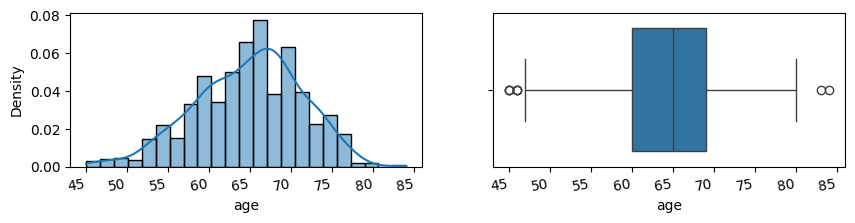


🟧🟧🟧 preop_PSA 🟧🟧🟧
n: 1180
n_unique: 667
Missing %: 0.0%
MIN: 0.313. MAX: 100.0
Median: 8.094999999999999
Mean: 10.89
Trimmed mean: 9.20
Mode: 8.0
IQR: 6.4925
5%: 4.11. 95%: 26.37
std: 8.88
cv: 0.81 ➡️ High Variability - noisy feature, check outliers|transforms
Skewness: 3.52 ➡️ Right-Skewed. Most data are "low"
Kurtosis: 18.77 ➡️ Leptokurtic. Many extreme "Black Swan" outliers


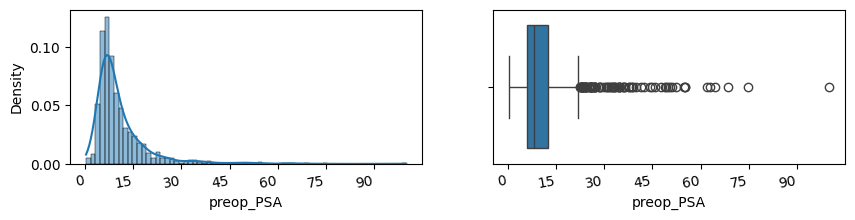


🟧🟧🟧 RPE_grade 🟧🟧🟧
n: 1180
n_unique: 5
Missing %: 0.0%
MIN: 1.0. MAX: 5.0
Median: 2.0
Mean: 2.23
Trimmed mean: 2.11
Mode: 2
IQR: 0.0
5%: 1.00. 95%: 5.00
std: 0.94
cv: 0.42 ➡️ Moderate Variability - normal clinical spread
Skewness: 1.32 ➡️ Right-Skewed. Most data are "low"
Kurtosis: 1.98 ➡️ Leptokurtic. Many extreme "Black Swan" outliers


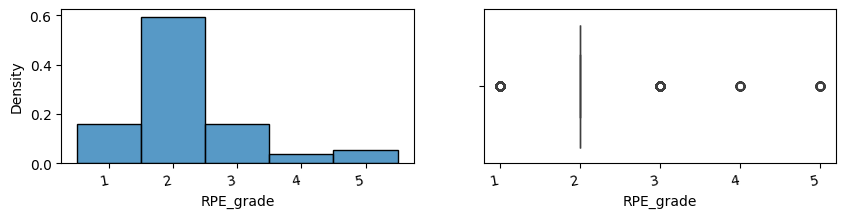


🟧🟧🟧 biopsy_to_RPE_days 🟧🟧🟧
n: 1180
n_unique: 310
Missing %: 0.0%
MIN: 0.0. MAX: 3326.0
Median: 119.0
Mean: 173.71
Trimmed mean: 129.66
Mode: 89, 105
IQR: 76.0
5%: 62.00. 95%: 427.05
std: 232.79
cv: 1.34 ➡️ Extreme Variability - highly chaotic relative to mean; interpret with caution
Skewness: 7.14 ➡️ Right-Skewed. Most data are "low"
Kurtosis: 70.18 ➡️ Leptokurtic. Many extreme "Black Swan" outliers


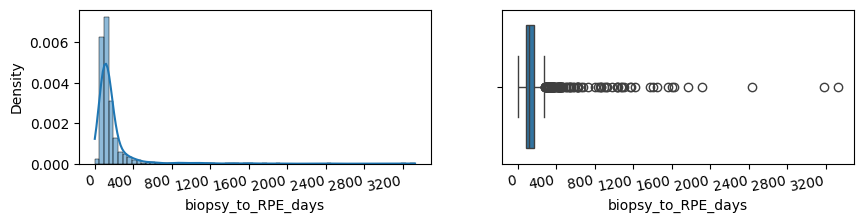


🟧🟧🟧 prostate_volume 🟧🟧🟧
n: 1180
n_unique: 328
Missing %: 0.0%
MIN: 2.0. MAX: 178.0
Median: 39.0
Mean: 43.87
Trimmed mean: 41.04
Mode: 40.0
IQR: 22.0
5%: 20.00. 95%: 85.00
std: 20.83
cv: 0.47 ➡️ Moderate Variability - normal clinical spread
Skewness: 1.72 ➡️ Right-Skewed. Most data are "low"
Kurtosis: 4.55 ➡️ Leptokurtic. Many extreme "Black Swan" outliers


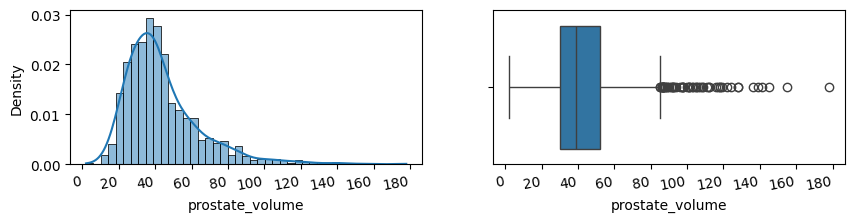


🟧🟧🟧 PSA_density 🟧🟧🟧
n: 1180
n_unique: 303
Missing %: 0.0%
MIN: 0.02. MAX: 4.55
Median: 0.21
Mean: 0.29
Trimmed mean: 0.24
Mode: 0.14
IQR: 0.2
5%: 0.08. 95%: 0.79
std: 0.30
cv: 1.03 ➡️ Extreme Variability - highly chaotic relative to mean; interpret with caution
Skewness: 5.84 ➡️ Right-Skewed. Most data are "low"
Kurtosis: 59.05 ➡️ Leptokurtic. Many extreme "Black Swan" outliers


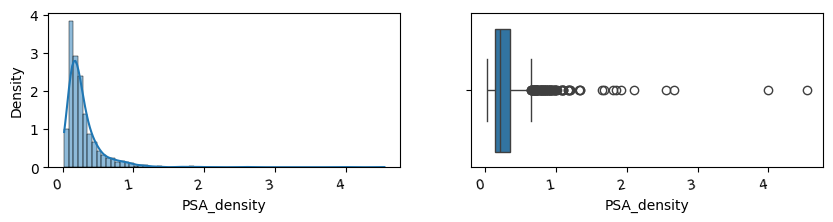

,column,n,n_unique,missing_%,max,min,median,mean,mode,std,cv,trimmed_mean,iqrange,p_5th,p_95th,skewness,kurtosis
0,age,1180,38,0.00,84,45,65.0,64.797,['67'],6.498,0.100,65.014,9.00,53.95,75.00,-0.32,-0.13
1,preop_PSA,1180,667,0.00,100,0,8.1,10.893,['8.0'],8.877,0.815,9.196,6.49,4.11,26.37,3.52,18.77
2,RPE_grade,1180,5,0.00,5,1,2.0,2.234,['2'],0.944,0.423,2.112,0.00,1.00,5.00,1.32,1.98
3,biopsy_to_RPE_days,1180,310,0.00,3326,0,119.0,173.705,"['89', '105']",232.793,1.340,129.656,76.00,62.00,427.05,7.14,70.18
4,prostate_volume,1180,328,0.00,178,2,39.0,43.871,['40.0'],20.834,0.475,41.041,22.00,20.00,85.00,1.72,4.55
5,PSA_density,1180,303,0.00,5,0,0.2,0.295,['0.14'],0.304,1.032,0.241,0.20,0.08,0.79,5.84,59.05


🚦🚦🚦 🟧🟧🟧🟧🟧🟧 CATEGORICAL 🟧🟧🟧🟧🟧🟧 🚦🚦🚦

🟧🟧🟧 lesion_1_MRI_PIRADS 🟧🟧🟧
n: 1180
Unique count: 5
Cardinality: 5 ➡️ Very low ➡️ Ideal for standard one-hot|tree models
missing_pct: 0.00%
First MODE: 5
Proportion of MODE: 45.08%
second_mode: 4
second_mode_pct: 42.63%
rarest: 1: 0.00%
max_class_imbalance: 1.06
Imbalance ratio: 1.06 ➡️ Classes are similarly frequent ➡️ No special handling needed
median_category: 4
Entropy: 1.58 ➡️ The Sweet Spot ➡️ Healthy clinical variety ➡️ best action --> GOLDEN. This is the best for ML
Balance: 0.68 ➡️ Healthy Diversity ➡️ Perfect. This is rich data for modeling


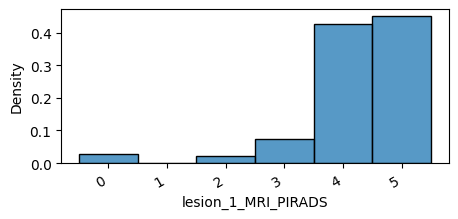


🟧🟧🟧 lesion_2_MRI_PIRADS 🟧🟧🟧
n: 293
Unique count: 4
Cardinality: 4 ➡️ Very low ➡️ Ideal for standard one-hot|tree models
missing_pct: 75.17%
First MODE: 4
Proportion of MODE: 60.41%
second_mode: 3
second_mode_pct: 25.26%
rarest: 1: 0.00%
max_class_imbalance: 2.39
Imbalance ratio: 2.39 ➡️ Mild dominance of the top class ➡️ Usually fine, just monitor minority performance
median_category: 4
Entropy: 1.47 ➡️ Low Diversity ➡️ Usually binary or heavily skewed (e.g., Gender, Yes/No) ➡️ best action --> Keep. Best for root nodes in decision trees
Balance: 0.74 ➡️ Broad Diversity ➡️ Rich spread across categories. Usually keep; review for fragmentation if many categories are clinically tiny


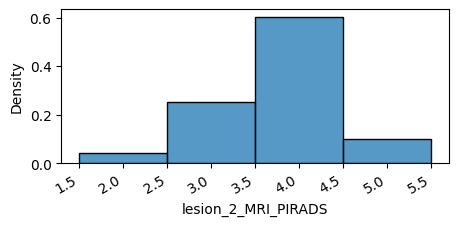


🟧🟧🟧 lesion_3_MRI_PIRADS 🟧🟧🟧
n: 35
Unique count: 4
Cardinality: 4 ➡️ Very low ➡️ Ideal for standard one-hot|tree models
missing_pct: 97.03%
First MODE: 3
Proportion of MODE: 45.71%
second_mode: 4
second_mode_pct: 37.14%
rarest: 1: 0.00%
max_class_imbalance: 1.23
Imbalance ratio: 1.23 ➡️ Classes are similarly frequent ➡️ No special handling needed
median_category: 3
Entropy: 1.64 ➡️ The Sweet Spot ➡️ Healthy clinical variety ➡️ best action --> GOLDEN. This is the best for ML
Balance: 0.82 ➡️ Broad Diversity ➡️ Rich spread across categories. Usually keep; review for fragmentation if many categories are clinically tiny


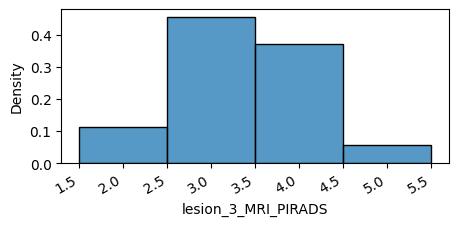


🟧🟧🟧 risk_group 🟧🟧🟧
n: 1180
Unique count: 3
Cardinality: 3 ➡️ Very low ➡️ Ideal for standard one-hot|tree models
missing_pct: 0.00%
First MODE: vidēja
Proportion of MODE: 45.17%
second_mode: augsta
second_mode_pct: 36.36%
rarest: zema: 18.47%
max_class_imbalance: 1.24
Imbalance ratio: 1.24 ➡️ Classes are similarly frequent ➡️ No special handling needed
median_category: vidēja
Entropy: 1.50 ➡️ Low Diversity ➡️ Usually binary or heavily skewed (e.g., Gender, Yes/No) ➡️ best action --> Keep. Best for root nodes in decision trees
Balance: 0.95 ➡️ Near-Uniform Spread ➡️ Values are distributed almost equally. Check whether this reflects true diversity or fragmented noise / ID-like categories


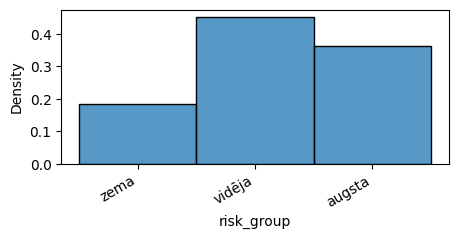


🟧🟧🟧 biopsy_gleason_grade 🟧🟧🟧
n: 1180
Unique count: 5
Cardinality: 5 ➡️ Very low ➡️ Ideal for standard one-hot|tree models
missing_pct: 0.00%
First MODE: 2
Proportion of MODE: 42.54%
second_mode: 1
second_mode_pct: 37.20%
rarest: 5: 2.88%
max_class_imbalance: 1.14
Imbalance ratio: 1.14 ➡️ Classes are similarly frequent ➡️ No special handling needed
median_category: 2
Entropy: 1.80 ➡️ The Sweet Spot ➡️ Healthy clinical variety ➡️ best action --> GOLDEN. This is the best for ML
Balance: 0.78 ➡️ Broad Diversity ➡️ Rich spread across categories. Usually keep; review for fragmentation if many categories are clinically tiny


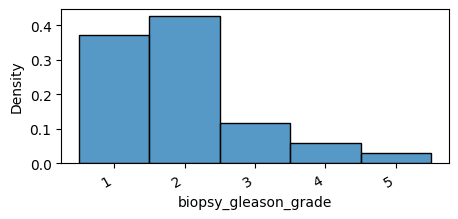

,col_name,n,n_unique,missing_pct,first_mode,second_mode,rarest,first_mode_pct,second_mode_pct,max_class_imbalance,median_category,balance,entropy_bin
0,lesion_1_MRI_PIRADS,1180,5,0.00,5,4,1: 0.00%,45.08,42.63,1.06,4,0.68,1.58
1,lesion_2_MRI_PIRADS,293,4,75.17,4,3,1: 0.00%,60.41,25.26,2.39,4,0.74,1.47
2,lesion_3_MRI_PIRADS,35,4,97.03,3,4,1: 0.00%,45.71,37.14,1.23,3,0.82,1.64
3,risk_group,1180,3,0.00,vidēja,augsta,zema: 18.47%,45.17,36.36,1.24,vidēja,0.95,1.50
4,biopsy_gleason_grade,1180,5,0.00,2,1,5: 2.88%,42.54,37.20,1.14,2,0.78,1.80


🚦🚦🚦 🟧🟧🟧🟧🟧🟧 BINARY 🟧🟧🟧🟧🟧🟧 🚦🚦🚦

🟧🟧🟧 biopsy_type 🟧🟧🟧
n: 1180
Missing %: 0.00%
p1 (transrektāla): 0.64
p0 (transperineāla): 0.36
MODE: transrektāla
MODE %: 64.07%
Balance: 0.72 ➡️ Healthy Balance - great for modeling
Entropy:0.94 ➡️ High entropy - close to 50/50. Maximally informative for splits; great for ML


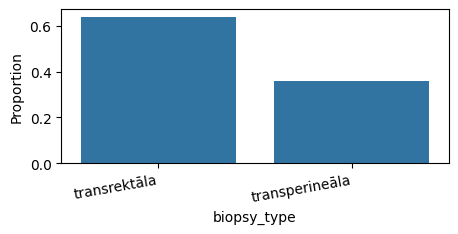


🟧🟧🟧 upgrade 🟧🟧🟧
n: 1180
Missing %: 0.00%
p1 (False): 0.64
p0 (True): 0.36
MODE: False
MODE %: 64.41%
Balance: 0.71 ➡️ Healthy Balance - great for modeling
Entropy:0.94 ➡️ High entropy - close to 50/50. Maximally informative for splits; great for ML


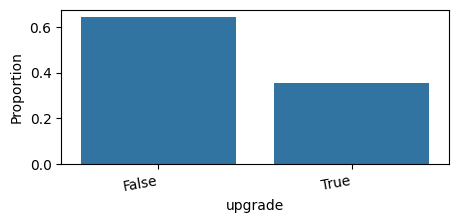


🟧🟧🟧 upstage 🟧🟧🟧
n: 1180
Missing %: 0.00%
p1 (False): 0.56
p0 (True): 0.44
MODE: False
MODE %: 55.51%
Balance: 0.89 ➡️ Healthy Balance - great for modeling
Entropy:0.99 ➡️ High entropy - close to 50/50. Maximally informative for splits; great for ML


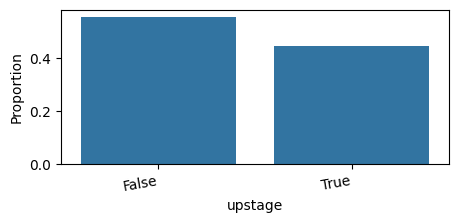


🟧🟧🟧 downgrade 🟧🟧🟧
n: 1180
Missing %: 0.00%
p1 (False): 0.88
p0 (True): 0.12
MODE: False
MODE %: 87.88%
Balance: 0.24 ➡️ Heavy Imbalance - rare positives/negatives. Handle with care
Entropy:0.53 ➡️ Moderate entropy - decent mix, but still some skew. Often fine for modeling


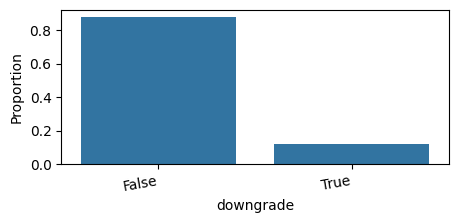


🟧🟧🟧 resection_lines_pos 🟧🟧🟧
n: 1180
Missing %: 0.00%
p1 (False): 0.93
p0 (True): 0.07
MODE: False
MODE %: 93.47%
Balance: 0.13 ➡️ Heavy Imbalance - rare positives/negatives. Handle with care
Entropy:0.35 ➡️ Moderate entropy - decent mix, but still some skew. Often fine for modeling


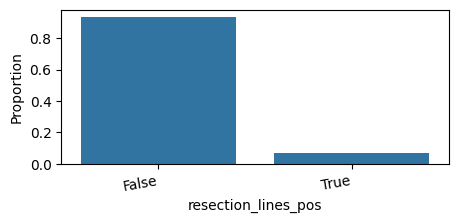

,column,n,missing_pct,p1,p0,mode,mode_pct,balance,entropy_bin
0,biopsy_type,1180,0.000,0.641,0.359,transrektāla,64.068,0.719,0.942
1,upgrade,1180,0.000,0.644,0.356,False,64.407,0.712,0.939
2,upstage,1180,0.000,0.555,0.445,False,55.508,0.890,0.991
3,downgrade,1180,0.000,0.879,0.121,False,87.881,0.242,0.533
4,resection_lines_pos,1180,0.000,0.935,0.065,False,93.475,0.131,0.348


In [8]:
project.keep_from_analysis(cols=["year", "pk", "preop_TNM_MDK", "RPE_TNM"])

project.analyse_numerical().analyse_categorical().analyse_binary()

In [10]:
project.export_all_overviews()

✅ Exported HTML report to: output/dda_all_overviews_report.html
✅ Exported vector figures (SVG) to: output/figures_svg


In [11]:
df.head()

,year,biopsy_type,lesion_1_MRI_PIRADS,lesion_2_MRI_PIRADS,lesion_3_MRI_PIRADS,age,preop_PSA,preop_TNM_MDK,risk_group,biopsy_gleason_grade,RPE_grade,biopsy_to_RPE_days,prostate_volume,upgrade,upstage,downgrade,RPE_TNM,PSA_density,resection_lines_pos,pk
0,2020,transrektāla,5,NaN,NaN,57,16.20,T2cN0M0,augsta,2,2,194,41.0,False,False,False,T2cN0M0,0.40,False,280362-12350
1,2020,transrektāla,0,NaN,NaN,64,10.40,T2N1M0,augsta,2,2,169,26.2,False,False,False,T2cN0M0,0.40,False,010855-11322
2,2020,transrektāla,3,2,NaN,45,5.55,T2aN0M0,zema,1,1,142,38.0,False,False,False,T2aN0M0,0.15,False,100474-10701
3,2020,transrektāla,5,NaN,NaN,58,11.60,T3bN0M0,augsta,3,5,122,37.0,True,False,False,T3bN1M0,0.31,False,200861-11455
4,2020,transrektāla,5,3,3,76,7.24,T2cN0M0,augsta,2,2,107,60.0,False,False,False,T2cN0M0,0.12,False,061143-11286
